# Question 2

AhmadReza Nopoush

610301194

## Data prepration

In [1]:
# check that cuda is available
import torch
if not torch.cuda.is_available():
    print("CUDA is not available. Please check your CUDA installation.")

In [2]:
import os
import shutil
import zipfile
from google.colab import drive

# 1. Mount Google Drive
print("Mounting Google Drive...")
drive.mount('/content/drive')

# --- Configuration ---
DATA_DIR = "./LSVH_Data"
os.makedirs(DATA_DIR, exist_ok=True)

# 2. Define the path to your file
# Based on your screenshot, it is in the main folder named 'lsvh_owned.zip'
source_path = "/content/drive/MyDrive/LSVH_.zip"
dest_path = f"{DATA_DIR}/lsvh.zip"

# 3. Copy the file from Drive to Colab
# This is faster than extracting directly from Drive
print(f"Looking for file at: {source_path}")

if os.path.exists(source_path):
    print("✅ File found! Copying to local environment (3.35 GB)...")
    shutil.copy(source_path, dest_path)
    print("Copy complete.")
else:
    print(f"\n❌ ERROR: File not found at {source_path}")
    print("Please verify the file name is exactly 'lsvh_owned.zip' in your main Drive folder.")
    raise FileNotFoundError("Dataset not found")

# 4. Extract the ZIP file
print("Extracting ZIP...")
with zipfile.ZipFile(dest_path, 'r') as zip_ref:
    zip_ref.extractall(DATA_DIR)

print("Extraction complete!")

# 5. Show what was extracted
print("\nScanning extracted dataset...\n")
for root, dirs, files in os.walk(DATA_DIR):
    level = root.replace(DATA_DIR, '').count(os.sep)
    if level < 2:
        print(f"{' '*4*level}{os.path.basename(root)}/")
        for f in files[:5]:
            print(f"{' '*4*(level+1)}{f}")


Mounting Google Drive...
Mounted at /content/drive
Looking for file at: /content/drive/MyDrive/LSVH_.zip
✅ File found! Copying to local environment (3.35 GB)...
Copy complete.
Extracting ZIP...
Extraction complete!

Scanning extracted dataset...

LSVH_Data/
    lsvh.zip
    LSVH/
        train.txt
        test.txt
        README.txt


#### raw data

Showing: Sparse-12-4578.jpg


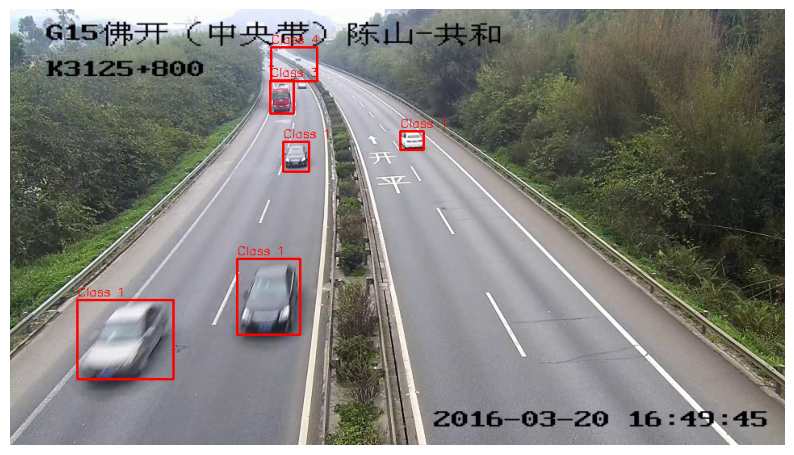

In [30]:
import os
import random
import cv2
import matplotlib.pyplot as plt

IMG_DIR = "LSVH_Data/LSVH/images"
LBL_DIR = "LSVH_Data/LSVH/labels"

def show_kitti_image(img_name):
    img_path = os.path.join(IMG_DIR, img_name)
    lbl_path = os.path.join(LBL_DIR, img_name.replace(".jpg", ".txt"))

    # Load image
    img = cv2.imread(img_path)
    if img is None:
        print("Error loading image:", img_path)
        return

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # If no label file exists
    if not os.path.exists(lbl_path):
        print("No annotation found for:", img_name)
        plt.imshow(img)
        plt.axis("off")
        plt.show()
        return

    # Read KITTI annotation
    with open(lbl_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.split()

        cls_id = int(parts[0])     # 1 = Car, 2 = Bus, 3 = Van
        x1 = float(parts[4])
        y1 = float(parts[5])
        x2 = float(parts[6])
        y2 = float(parts[7])

        # Draw bounding box
        cv2.rectangle(img,
                      (int(x1), int(y1)),
                      (int(x2), int(y2)),
                      (255, 0, 0), 2)

        cv2.putText(img, f"Class {cls_id}",
                    (int(x1), int(y1)-5),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5, (255, 0, 0), 1)

    plt.figure(figsize=(10,8))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

# ---- Show a random image ----
sample_img = random.choice(os.listdir(IMG_DIR))
print("Showing:", sample_img)
show_kitti_image(sample_img)


#### readining annotations

In [31]:
import os
import json

# --- Paths ---
ROOT_DIR = "LSVH_Data/LSVH"
IMG_DIR = os.path.join(ROOT_DIR, "images")
LBL_DIR = os.path.join(ROOT_DIR, "labels")

# --- Class mapping ---
CLASS_MAP = {
    1: "Car",
    2: "Bus",
    3: "Van",
    4: "DontCare"  # we will remove these
}

# --- Output structure ---
# We will save per image:
# { "image_path": str, "boxes": [[x1,y1,x2,y2,...]], "labels": [str,...] }
dataset_annotations = []

# --- Process all images ---
for img_file in os.listdir(IMG_DIR):
    if not img_file.lower().endswith((".jpg", ".png", ".jpeg")):
        continue

    img_path = os.path.join(IMG_DIR, img_file)
    lbl_path = os.path.join(LBL_DIR, img_file.replace(".jpg", ".txt"))

    if not os.path.exists(lbl_path):
        continue  # skip images without annotation

    boxes = []
    labels = []

    with open(lbl_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        if len(parts) < 8:
            continue

        cls_id = int(parts[0])
        if cls_id == 4:
            continue  # skip "Don't care"
        if cls_id not in CLASS_MAP:
            continue  # skip unknown classes

        x1 = float(parts[4])
        y1 = float(parts[5])
        x2 = float(parts[6])
        y2 = float(parts[7])

        boxes.append([x1, y1, x2, y2])
        labels.append(cls_id)

    if boxes:
        dataset_annotations.append({
            "image_path": img_path,
            "boxes": boxes,
            "labels": labels
        })

print(f"Processed {len(dataset_annotations)} images with valid annotations.")

# --- Optional: Save annotations to JSON ---
output_json = os.path.join(ROOT_DIR, "LSVH_annotations.json")
with open(output_json, "w") as f:
    json.dump(dataset_annotations, f, indent=2)

print(f"Saved processed annotations to {output_json}")


Processed 13938 images with valid annotations.
Saved processed annotations to LSVH_Data/LSVH/LSVH_annotations.json


In [32]:
dataset_annotations[0]

{'image_path': 'LSVH_Data/LSVH/images/Sparse-07-3263.jpg',
 'boxes': [[254.0, 116.0, 277.0, 132.0], [444.0, 110.0, 469.0, 134.0]],
 'labels': [1, 1]}

#### prepared data

Total images with annotations: 13938


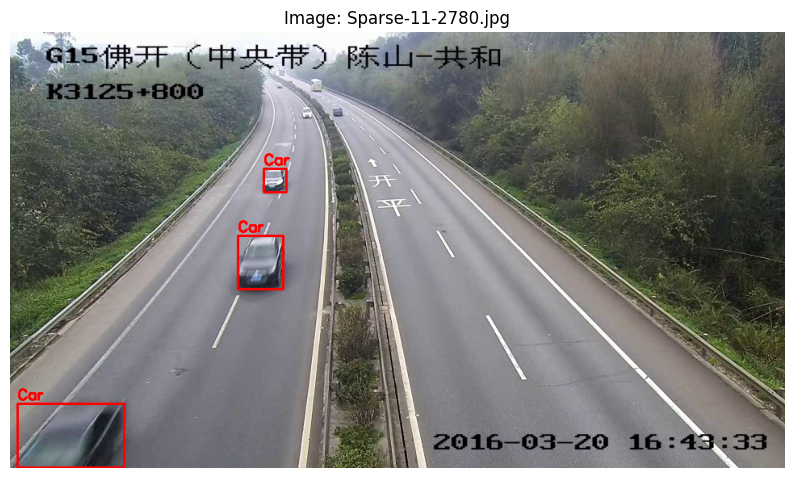

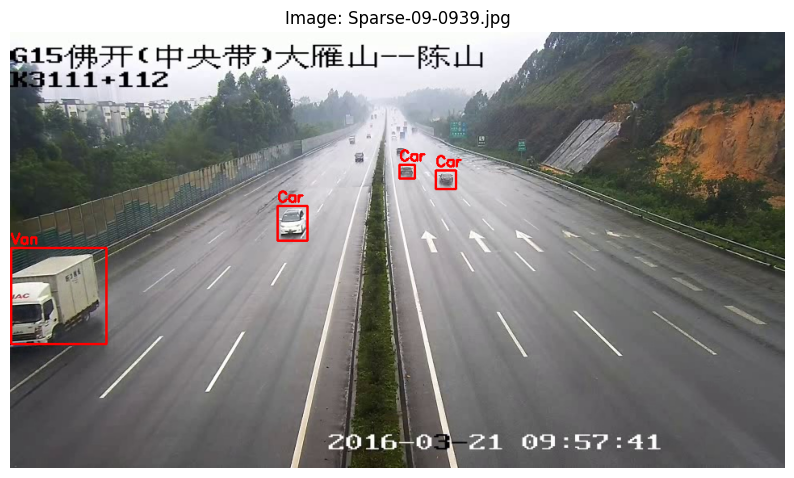

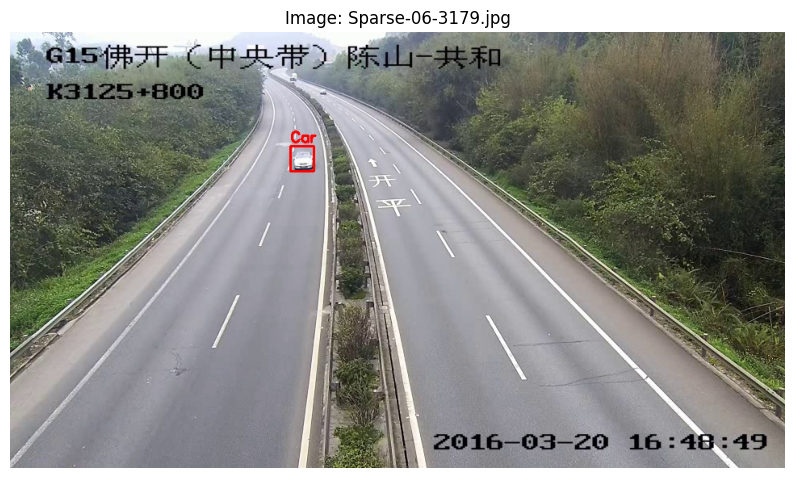

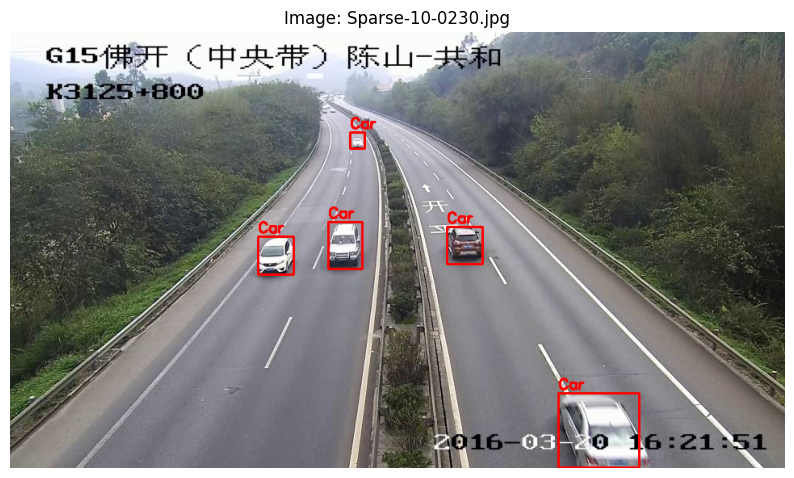

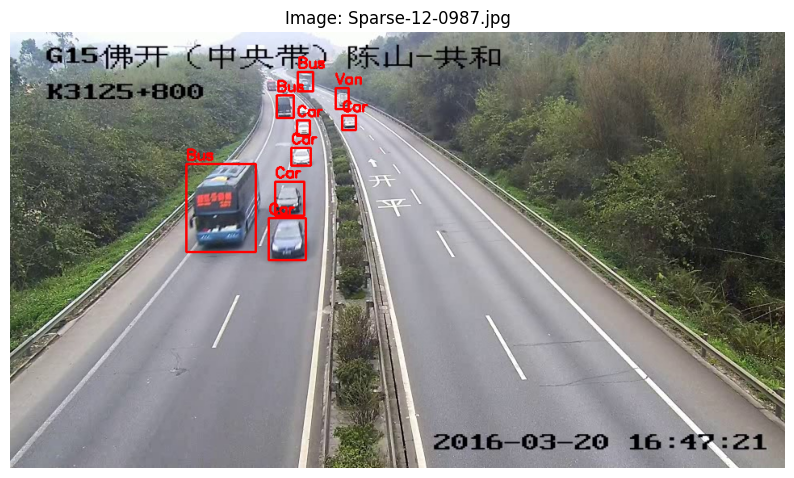

In [33]:
import json
import random
import cv2
import matplotlib.pyplot as plt
import os

# --- Path to preprocessed JSON ---
ANNOT_JSON = "LSVH_Data/LSVH/LSVH_annotations.json"

# --- Load annotations ---
with open(ANNOT_JSON, "r") as f:
    annotations = json.load(f)

print(f"Total images with annotations: {len(annotations)}")

# --- Number of sample images to display ---
NUM_SAMPLES = 5

# --- Randomly select sample images ---
samples = random.sample(annotations, min(NUM_SAMPLES, len(annotations)))

# --- Display each sample ---
for sample in samples:
    img_path = sample["image_path"]
    boxes = sample["boxes"]
    labels = sample["labels"]

    # Load image
    img = cv2.imread(img_path)
    if img is None:
        print("Error loading image:", img_path)
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Draw all bounding boxes
    for box, label in zip(boxes, labels):
        x1, y1, x2, y2 = box
        cv2.rectangle(img, (int(x1), int(y1)), (int(x2), int(y2)), (255, 0, 0), 2)
        cv2.putText(img, CLASS_MAP[label], (int(x1), int(y1)-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)

    # Show the image
    plt.figure(figsize=(10,8))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Image: {os.path.basename(img_path)}")
    plt.show()


### data preprocessing

In [52]:
import numpy as np

class2int = {'background':0, 'Car':1, 'Bus':2, 'Van':3}
int2class = {0:'background', 1:'Car', 2:'Bus', 3:'Van'}

print(class2int)
print(int2class)

{'background': 0, 'Car': 1, 'Bus': 2, 'Van': 3}
{0: 'background', 1: 'Car', 2: 'Bus', 3: 'Van'}


In [53]:
import os
import json

# --- Paths ---
ROOT_DIR = "LSVH_Data/LSVH"
IMG_DIR = os.path.join(ROOT_DIR, "images")
LBL_DIR = os.path.join(ROOT_DIR, "labels")
TRAIN_LIST = os.path.join(ROOT_DIR, "train.txt")
TEST_LIST = os.path.join(ROOT_DIR, "test.txt")

# --- Class mapping ---
CLASS_MAP = {
    1: "Car",
    2: "Bus",
    3: "Van",
    4: "DontCare"  # we will remove these
}

# --- Function to read a label file ---
def read_label_file(lbl_path):
    boxes = []
    labels = []
    with open(lbl_path, "r") as f:
        lines = f.readlines()
    for line in lines:
        parts = line.strip().split()
        if len(parts) < 8:
            continue
        cls_id = int(parts[0])
        if cls_id == 4 or cls_id not in CLASS_MAP:
            continue
        x1, y1, x2, y2 = map(float, parts[4:8])
        boxes.append([x1, y1, x2, y2])
        labels.append(cls_id)

    if len(boxes) == 0:
        return None, None
    return boxes, labels

# --- Load train/test image lists ---
with open(TRAIN_LIST, "r") as f:
    train_files = set(line.strip() for line in f.readlines())

with open(TEST_LIST, "r") as f:
    test_files = set(line.strip() for line in f.readlines())

# --- Process all images and split ---
train_data = []
test_data = []

for img_file in os.listdir(IMG_DIR):
    if not img_file.lower().endswith((".jpg")):
        continue

    img_path = os.path.join(IMG_DIR, img_file)
    lbl_path = os.path.join(LBL_DIR, img_file.replace(".jpg", ".txt"))

    if not os.path.exists(lbl_path):
        continue

    boxes, labels = read_label_file(lbl_path)
    if boxes is None:
        continue  # skip images without valid boxes

    record = {
        "image_path": img_path,
        "boxes": boxes,
        "labels": labels
    }

    # Split based on filename in train/test lists
    if img_file[:-4] in train_files:
        train_data.append(record)
    elif img_file[:-4] in test_files:
        test_data.append(record)

print(f"Train images: {len(train_data)}")
print(f"Test images: {len(test_data)}")

Train images: 9701
Test images: 4237


In [54]:
from torch.utils.data import DataLoader, Dataset

class LSVHDataSet(Dataset):
    def __init__(self, dataframe, transforms=None, resize_factor=1):

        super().__init__()

        self.df = dataframe
        self.transforms = transforms
        self.resize_factor = resize_factor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index: int):

        #Retrive Image name and its records (x1, y1, x2, y2, classname) from df
        image_path = self.df[index]['image_path']
        records = self.df[index]

        #Loading Image
        image = cv2.imread(image_path, cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB).astype(np.float32)
        image /= 255.0


        #Get bounding box co-ordinates for each box
        boxes = self.df[index]['boxes']

        #Getting labels for each box
        labels = self.df[index]['labels']

        #Converting boxes & labels into torch tensor
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        # Resize the image and the bounding boxes
        height, width, _ = image.shape
        new_height, new_width = int(height * self.resize_factor), int(width * self.resize_factor)
        image = cv2.resize(image, (new_width, new_height))
        boxes = boxes * self.resize_factor
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])

        #Creating target
        target = {}
        target['boxes'] = boxes
        target['labels'] = labels


        #Transforms
        if self.transforms:
            image = self.transforms(image)


        return image, target, image_path


In [55]:
import torchvision.transforms as T

def get_transform():
    return T.Compose([
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])


def collate_fn(batch):
    return tuple(zip(*batch))

#### data splition

In [56]:
random.seed(89)

# Select 40% of training data
train_40_percent = random.sample(train_data, int(0.40 * len(train_data)))

# Split into 90% train / 10% val
train_size = int(0.9 * len(train_40_percent))
val_size = len(train_40_percent) - train_size

train_dataset_list = train_40_percent[:train_size]
val_dataset_list   = train_40_percent[train_size:]

test_dataset_list = random.sample(test_data, int(0.20 * len(test_data)))


#### define dataloader

In [57]:
BATCH_SIZE = 8

train_dataset = LSVHDataSet(train_dataset_list, transforms = get_transform())
validation_dataset   = LSVHDataSet(val_dataset_list, transforms = get_transform())

# Preparing data loaders
train_dataloader = DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers = 2,
    collate_fn = collate_fn
)


validation_dataloader = DataLoader(
    validation_dataset,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers = 2,
    collate_fn = collate_fn
)

## Paper Model

In [73]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import math

# ---------------- Backbone ----------------
class MobileNetV2Backbone(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        mobilenet = models.mobilenet_v2(weights="DEFAULT")
        self.features = mobilenet.features
        # Freeze backbone
        for param in self.features.parameters():
            param.requires_grad = False

    def forward(self, x):
        return self.features(x)


# FIX: Updated RPN without inplace operations
class RPN(nn.Module):
    def __init__(self, in_channels=1280, nms_thresh=0.5, score_thresh=0.005,
                 pre_nms_top_n=256, post_nms_top_n=64):
        super().__init__()
        self.in_channels = in_channels
        self.nms_thresh = nms_thresh
        self.score_thresh = score_thresh
        self.pre_nms_top_n = pre_nms_top_n
        self.post_nms_top_n = post_nms_top_n

        self.scales = [128, 256, 512]
        self.ratios = [1.0, 0.5, 2.0]
        self.stride = 32
        self.num_anchors = len(self.scales) * len(self.ratios)

        self.conv = nn.Conv2d(in_channels, 512, kernel_size=3, padding=1)
        self.cls_layer = nn.Conv2d(512, self.num_anchors * 2, kernel_size=1)
        self.reg_layer = nn.Conv2d(512, self.num_anchors * 4, kernel_size=1)

        self._init_weights()

    def _init_weights(self):
        for layer in [self.conv, self.cls_layer, self.reg_layer]:
            nn.init.normal_(layer.weight, std=0.01)
            nn.init.constant_(layer.bias, 0)

    def generate_anchors_single_feature_map(self, H, W, stride, device):
        shifts_x = torch.arange(W, device=device) * stride + stride / 2
        shifts_y = torch.arange(H, device=device) * stride + stride / 2
        shift_y, shift_x = torch.meshgrid(shifts_y, shifts_x, indexing="ij")
        shift_x = shift_x.reshape(-1)
        shift_y = shift_y.reshape(-1)

        anchors = []
        for scale in self.scales:
            for ratio in self.ratios:
                h = scale * math.sqrt(ratio)
                w = scale / math.sqrt(ratio)
                x1 = shift_x - w / 2
                y1 = shift_y - h / 2
                x2 = shift_x + w / 2
                y2 = shift_y + h / 2
                anchors.append(torch.stack([x1, y1, x2, y2], dim=1))

        anchors = torch.cat(anchors, dim=0)
        return anchors

    def apply_deltas(self, anchors, deltas):
        widths = anchors[:, 2] - anchors[:, 0]
        heights = anchors[:, 3] - anchors[:, 1]
        cx = anchors[:, 0] + 0.5 * widths
        cy = anchors[:, 1] + 0.5 * heights

        dx = deltas[:, 0]
        dy = deltas[:, 1]
        dw = deltas[:, 2].clamp(max=4.0)
        dh = deltas[:, 3].clamp(max=4.0)

        pred_cx = dx * widths + cx
        pred_cy = dy * heights + cy
        pred_w = torch.exp(dw) * widths
        pred_h = torch.exp(dh) * heights

        pred_x1 = pred_cx - 0.5 * pred_w
        pred_y1 = pred_cy - 0.5 * pred_h
        pred_x2 = pred_cx + 0.5 * pred_w
        pred_y2 = pred_cy + 0.5 * pred_h

        return torch.stack([pred_x1, pred_y1, pred_x2, pred_y2], dim=1)

    def linear_soft_nms(self, boxes, scores):
        """Fixed Soft-NMS without inplace operations"""
        if boxes.size(0) == 0:
            return boxes, scores

        P_temp_boxes = boxes.clone()
        P_temp_scores = scores.clone()

        P_out_boxes = []
        P_out_scores = []

        max_output = self.post_nms_top_n

        while P_temp_boxes.size(0) > 0 and len(P_out_boxes) < max_output:
            max_idx = torch.argmax(P_temp_scores)
            winner_box = P_temp_boxes[max_idx]
            winner_score = P_temp_scores[max_idx]

            P_out_boxes.append(winner_box)
            P_out_scores.append(winner_score)

            # Create mask without inplace operation
            mask = torch.ones(P_temp_boxes.size(0), dtype=torch.bool, device=boxes.device)
            mask = mask.clone()  # Ensure it's not a view
            mask[max_idx] = False

            boxes_rest = P_temp_boxes[mask]
            scores_rest = P_temp_scores[mask]

            if boxes_rest.size(0) == 0:
                break

            ious = self.iou(boxes_rest, winner_box.unsqueeze(0)).squeeze(1)
            neighbor_mask = ious > self.nms_thresh

            # FIX: Avoid inplace operation
            scores_rest = scores_rest.clone()  # Create a copy
            scores_rest[neighbor_mask] = scores_rest[neighbor_mask] * (1 - ious[neighbor_mask])

            keep = scores_rest >= self.score_thresh
            P_temp_boxes = boxes_rest[keep]
            P_temp_scores = scores_rest[keep]

        if len(P_out_boxes) == 0:
            return torch.zeros((0, 4), device=boxes.device), torch.zeros((0,), device=boxes.device)

        return torch.stack(P_out_boxes), torch.stack(P_out_scores)

    def iou(self, boxes1, boxes2):
        x11, y11, x12, y12 = boxes1[:, 0], boxes1[:, 1], boxes1[:, 2], boxes1[:, 3]
        x21, y21, x22, y22 = boxes2[:, 0], boxes2[:, 1], boxes2[:, 2], boxes2[:, 3]

        xA = torch.max(x11.unsqueeze(1), x21)
        yA = torch.max(y11.unsqueeze(1), y21)
        xB = torch.min(x12.unsqueeze(1), x22)
        yB = torch.min(y12.unsqueeze(1), y22)

        inter = (xB - xA).clamp(min=0) * (yB - yA).clamp(min=0)
        area1 = (x12 - x11) * (y12 - y11)
        area2 = (x22 - x21) * (y22 - y21)

        return inter / (area1.unsqueeze(1) + area2 - inter + 1e-6)

    def forward(self, feature_map, image_shape=None):
        B, C, H, W = feature_map.shape
        device = feature_map.device

        x = F.relu(self.conv(feature_map))

        cls_logits = self.cls_layer(x)
        cls_logits = cls_logits.permute(0, 2, 3, 1).contiguous().reshape(B, -1, 2)  # Added contiguous()

        bbox_deltas = self.reg_layer(x)
        bbox_deltas = bbox_deltas.permute(0, 2, 3, 1).contiguous().reshape(B, -1, 4)  # Added contiguous()

        anchors = self.generate_anchors_single_feature_map(H, W, self.stride, device)

        proposals_list = []

        for b in range(B):
            scores = F.softmax(cls_logits[b].detach(), dim=-1)[:, 1]  # Detach for NMS

            if scores.size(0) > self.pre_nms_top_n:
                top_scores, top_idx = scores.topk(self.pre_nms_top_n)
                scores = top_scores
                anchors_b = anchors[top_idx]
                deltas_b = bbox_deltas[b][top_idx].detach()  # Detach
            else:
                anchors_b = anchors
                deltas_b = bbox_deltas[b].detach()  # Detach

            proposals = self.apply_deltas(anchors_b, deltas_b)

            if image_shape is not None:
                img_h, img_w = image_shape
                proposals = proposals.clone()  # Create copy before clamping
                proposals[:, 0] = proposals[:, 0].clamp(min=0, max=img_w)
                proposals[:, 1] = proposals[:, 1].clamp(min=0, max=img_h)
                proposals[:, 2] = proposals[:, 2].clamp(min=0, max=img_w)
                proposals[:, 3] = proposals[:, 3].clamp(min=0, max=img_h)

            ws = proposals[:, 2] - proposals[:, 0]
            hs = proposals[:, 3] - proposals[:, 1]
            keep = (ws >= 16) & (hs >= 16)
            proposals = proposals[keep]
            scores = scores[keep]

            if proposals.size(0) > 0:
                final_boxes, final_scores = self.linear_soft_nms(proposals, scores)
            else:
                final_boxes = torch.zeros((0, 4), device=device)

            proposals_list.append(final_boxes)

        return proposals_list, cls_logits, bbox_deltas, anchors


class CARoIPooling(nn.Module):
    def __init__(self, output_size=(14, 14)):
        super().__init__()
        self.out_h, self.out_w = output_size

    def forward(self, feature_map, proposals):
        """
        feature_map: [B, C, Hf, Wf]
        proposals: list of B tensors, each [N_i, 4] in FEATURE MAP coordinates
        """
        B, C, Hf, Wf = feature_map.shape
        output_list = []
        proposal_batch_idx = []  # Track which batch each proposal belongs to

        for b in range(B):
            if proposals[b].size(0) == 0:
                continue

            for i, (x1, y1, x2, y2) in enumerate(proposals[b]):
                # Clamp to feature map boundaries
                x1_int = max(0, int(x1.item()))
                y1_int = max(0, int(y1.item()))
                x2_int = min(Wf, int(x2.item()) + 1)
                y2_int = min(Hf, int(y2.item()) + 1)

                # Extract region
                region = feature_map[b:b+1, :, y1_int:y2_int, x1_int:x2_int]
                h, w = region.shape[2], region.shape[3]

                if h == 0 or w == 0:
                    # Handle empty regions - create zero tensor
                    region = torch.zeros((1, C, self.out_h, self.out_w),
                                        device=feature_map.device)
                else:
                    # Apply Context-Aware RoI Pooling logic
                    region = self._ca_pool(region, h, w)

                output_list.append(region)
                proposal_batch_idx.append(b)

        if len(output_list) == 0:
            return torch.zeros((0, C, self.out_h, self.out_w), device=feature_map.device)

        return torch.cat(output_list, dim=0)

    def _ca_pool(self, region, h, w):
        """
        Context-Aware pooling logic from paper
        """
        # Case 1: Both larger → maxpool
        if h >= self.out_h and w >= self.out_w:
            region = F.adaptive_max_pool2d(region, (self.out_h, self.out_w))

        # Case 2: Both smaller → upsample (bilinear instead of deconv)
        elif h < self.out_h and w < self.out_w:
            region = F.interpolate(region, size=(self.out_h, self.out_w),
                                   mode='bilinear', align_corners=False)

        # Case 3: height >= out, width < out
        elif h >= self.out_h and w < self.out_w:
            # Shrink height, enlarge width
            region = F.adaptive_max_pool2d(region, (self.out_h, w))
            region = F.interpolate(region, size=(self.out_h, self.out_w),
                                   mode='bilinear', align_corners=False)

        # Case 4: height < out, width >= out
        elif h < self.out_h and w >= self.out_w:
            # Enlarge height, shrink width
            region = F.interpolate(region, size=(self.out_h, w),
                                   mode='bilinear', align_corners=False)
            region = F.adaptive_max_pool2d(region, (self.out_h, self.out_w))

        return region


# Depthwise Separable Conv (MobileNet style)
class DWConv(nn.Module):
    def __init__(self, in_ch, out_ch, stride):
        super().__init__()
        self.dw = nn.Conv2d(in_ch, in_ch, kernel_size=3, stride=stride,
                            padding=1, groups=in_ch, bias=False)
        self.pw = nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=1, bias=False)
        self.bn1 = nn.BatchNorm2d(in_ch)
        self.bn2 = nn.BatchNorm2d(out_ch)

    def forward(self, x):
        x = F.relu(self.bn1(self.dw(x)))
        x = F.relu(self.bn2(self.pw(x)))
        return x


class CAROI_Classifier(nn.Module):
    def __init__(self, num_classes=4):  # 4 = background + Car + Bus + Van
        super().__init__()
        self.num_classes = num_classes

        in_ch = 1280

        # Block 1: DW conv (stride 2) → 1024
        self.block1 = DWConv(in_ch, 1024, stride=2)  # out: [N, 1024, 7, 7]

        # Block 2: DW conv (stride 1) → keep 1024
        self.block2 = DWConv(1024, 1024, stride=1)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        self.fc_class = nn.Linear(1024, num_classes)        # Multi-class
        self.fc_bbox = nn.Linear(1024, num_classes * 4)     # Class-specific bbox

    def forward(self, x):
        if x.size(0) == 0:
            device = x.device
            return (torch.zeros((0, self.num_classes), device=device),
                    torch.zeros((0, self.num_classes * 4), device=device))

        x = self.block1(x)
        x = self.block2(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)

        cls_scores = self.fc_class(x)
        bbox_deltas = self.fc_bbox(x)

        return cls_scores, bbox_deltas


class PaperModel(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.num_classes = num_classes
        self.backbone = MobileNetV2Backbone()
        self.rpn = RPN()
        self.caroipool = CARoIPooling()
        self.classifier = CAROI_Classifier(num_classes=num_classes)

    def forward(self, images, gt_boxes=None, gt_labels=None):
        """
        images: [B, 3, H, W]
        gt_boxes: list of B tensors [N_i, 4] (for training)
        gt_labels: list of B tensors [N_i] (for training)
        """
        B, _, img_h, img_w = images.shape

        # 1) Backbone
        fmap = self.backbone(images)
        _, _, fmap_h, fmap_w = fmap.shape

        # 2) RPN
        proposals, rpn_cls_logits, rpn_bbox_deltas, anchors = self.rpn(
            fmap, image_shape=(img_h, img_w)
        )

        # 3) Scale proposals to feature map coordinates
        scale_x = fmap_w / img_w
        scale_y = fmap_h / img_h

        scaled_proposals = []
        for b in range(B):
            if proposals[b].size(0) > 0:
                p = proposals[b].clone()
                p[:, [0, 2]] *= scale_x
                p[:, [1, 3]] *= scale_y
                scaled_proposals.append(p)
            else:
                scaled_proposals.append(proposals[b])

        # 4) CARoI Pooling
        pooled = self.caroipool(fmap, scaled_proposals)

        # 5) Classification
        cls_scores, bbox_deltas = self.classifier(pooled)

        return {
            'cls_scores': cls_scores,
            'bbox_deltas': bbox_deltas,
            'proposals': proposals,
            'rpn_cls_logits': rpn_cls_logits,
            'rpn_bbox_deltas': rpn_bbox_deltas,
            'anchors': anchors,
            'feature_map': fmap
        }

In [58]:
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor


#### pytorch class

In [59]:
model = torchvision.models.detection.fasterrcnn_mobilenet_v3_large_fpn(pretrained=True)

num_classes = 4

in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_MobileNet_V3_Large_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_MobileNet_V3_Large_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [60]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# Retriving all trainable parameters from model (for optimizer)
params = [p for p in model.parameters() if p.requires_grad]

# Defininig Optimizer
optimizer = torch.optim.Adam(params, lr = 0.0001, weight_decay=0.0005)

lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)
model.to(device)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): FrozenBatchNorm2d(16, eps=1e-05)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
            (1): FrozenBatchNorm2d(16, eps=1e-05)
            (2): ReLU(inplace=True)
          )
          (1): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): FrozenBatchNorm2d(16, eps=1e-05)
          )
        )
      )
      (2): InvertedResidual(
        (block):

#### Training functions

In [74]:
import torch
import math
import sys
import pandas as pd
import numpy as np
from tqdm import tqdm
from torchvision.ops import box_iou

# -----------------------------
# Helper functions
# -----------------------------

def compute_mAP(pred_boxes, pred_labels, pred_scores, gt_boxes, gt_labels, iou_thresh=0.5):
    """
    Simple mAP@0.5 calculation for one batch.
    pred_boxes: [N,4], pred_labels: [N], pred_scores: [N]
    gt_boxes: [M,4], gt_labels: [M]
    """
    if len(pred_boxes) == 0 or len(gt_boxes) == 0:
        return 0.0

    # Only consider predictions with score > 0.05
    keep = pred_scores > 0.05
    pred_boxes = pred_boxes[keep]
    pred_labels = pred_labels[keep]
    pred_scores = pred_scores[keep]

    aps = []

    for c in gt_labels.unique():
        gt_mask = gt_labels == c
        pred_mask = pred_labels == c

        gt_c = gt_boxes[gt_mask]
        pred_c = pred_boxes[pred_mask]
        pred_scores_c = pred_scores[pred_mask]

        if len(pred_c) == 0:
            aps.append(0.0)
            continue

        if len(gt_c) == 0:
            aps.append(0.0)
            continue

        ious = box_iou(pred_c, gt_c)
        tp = (ious.max(dim=1).values > iou_thresh).float()
        aps.append(tp.mean().item())

    return np.mean(aps)


def train_one_epoch(model, optimizer, loader, device, epoch):
    model.train()
    all_losses = []
    all_losses_dict = []

    for images, targets, _ in tqdm(loader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        loss_value = losses.item()

        all_losses.append(loss_value)
        all_losses_dict.append({k: v.item() for k, v in loss_dict.items()})

        if not math.isfinite(loss_value):
            print("Loss explosion:", loss_value)
            print(loss_dict)
            sys.exit(1)

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

    df = pd.DataFrame(all_losses_dict)
    avg_losses = {
        'epoch': epoch,
        'loss_total': np.mean(all_losses),
        'loss_classifier': df['loss_classifier'].mean(),
        'loss_box_reg': df['loss_box_reg'].mean(),
        'loss_objectness': df['loss_objectness'].mean(),
        'loss_rpn_box_reg': df['loss_rpn_box_reg'].mean()
    }

    return avg_losses

def evaluate_mAP(model, loader, device):
    model.eval()
    all_mAP = []

    with torch.no_grad():
        for images, targets, _ in tqdm(loader):
            images = [img.to(device) for img in images]
            outputs = model(images)  # only images, no targets

            for out, tgt in zip(outputs, targets):
                pred_boxes = out['boxes'].to('cpu')
                pred_labels = out['labels'].to('cpu')
                pred_scores = out['scores'].to('cpu')

                gt_boxes = tgt['boxes'].to('cpu')
                gt_labels = tgt['labels'].to('cpu')

                ap = compute_mAP(pred_boxes, pred_labels, pred_scores, gt_boxes, gt_labels)
                all_mAP.append(ap)

    return np.mean(all_mAP)


In [75]:
def validate_one_epoch(model, dataloader, device):
    model.train()      # ← IMPORTANT: force model to return losses
    val_loss = 0.0
    count = 0

    with torch.no_grad():   # no gradients
        for imgs, targets, image_ids in dataloader:

            imgs = [img.to(device) for img in imgs]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(imgs, targets)   # now returns dict
            loss = sum(loss_dict.values())

            val_loss += loss.item()
            count += 1

    return val_loss / count


## Train Model and Results

In [64]:
EPOCHS = 25

train_losses_history = []
val_losses_history = []
map_history = []
train_map_history = []

for epoch in range(EPOCHS):
    print(f"\n=== Epoch {epoch+1}/{EPOCHS} ===")



    # Train
    train_losses = train_one_epoch(model, optimizer, train_dataloader, device, epoch)
    train_losses_history.append(train_losses)
    print("Train Losses:", train_losses)

    # Train mAP
    if epoch%5==0:
        train_map = evaluate_mAP(model, train_dataloader, device)
        train_map_history.append({'epoch': epoch+1, 'mAP50_train': train_map})
        print(f"Train mAP@0.5: {train_map:.4f}")

    # Validation LOSS
    val_loss = validate_one_epoch(model, validation_dataloader, device)
    val_losses_history.append(val_loss)
    print(f"Validation Loss: {val_loss:.4f}")

    # Validation mAP
    if epoch%5==0:
        val_map = evaluate_mAP(model, validation_dataloader, device)
        map_history.append({'epoch': epoch+1, 'mAP50_val': val_map})
        print(f"Validation mAP@0.5: {val_map:.4f}")

    lr_scheduler.step()


=== Epoch 1/25 ===


100%|██████████| 437/437 [02:53<00:00,  2.52it/s]


Train Losses: {'epoch': 0, 'loss_total': np.float64(0.6934535041690145), 'loss_classifier': np.float64(0.2588891991897906), 'loss_box_reg': np.float64(0.4106378029153876), 'loss_objectness': np.float64(0.009449197323321529), 'loss_rpn_box_reg': np.float64(0.014477303943722519)}


100%|██████████| 437/437 [02:03<00:00,  3.53it/s]

Train mAP@0.5: 0.6297


...

Train Losses: {'epoch': 23, 'loss_total': np.float64(0.6198825237407292), 'loss_classifier': np.float64(0.2095434952621056), 'loss_box_reg': np.float64(0.39269210275441613), 'loss_objectness': np.float64(0.0068953747978834625), 'loss_rpn_box_reg': np.float64(0.01075154965188252)}


Validation Loss: 0.7357

=== Epoch 25/25 ===


100%|██████████| 437/437 [02:47<00:00,  2.62it/s]

Train Losses: {'epoch': 24, 'loss_total': np.float64(0.6191044079493604), 'loss_classifier': np.float64(0.209542622487114), 'loss_box_reg': np.float64(0.39202364644960624), 'loss_objectness': np.float64(0.0068003971741568865), 'loss_rpn_box_reg': np.float64(0.010737741131066968)}


Validation Loss: 0.7346


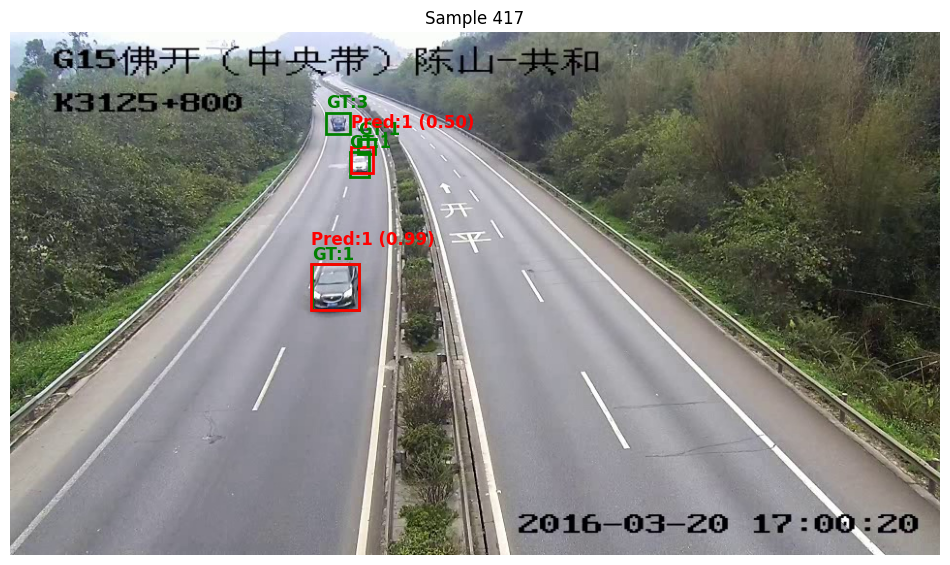

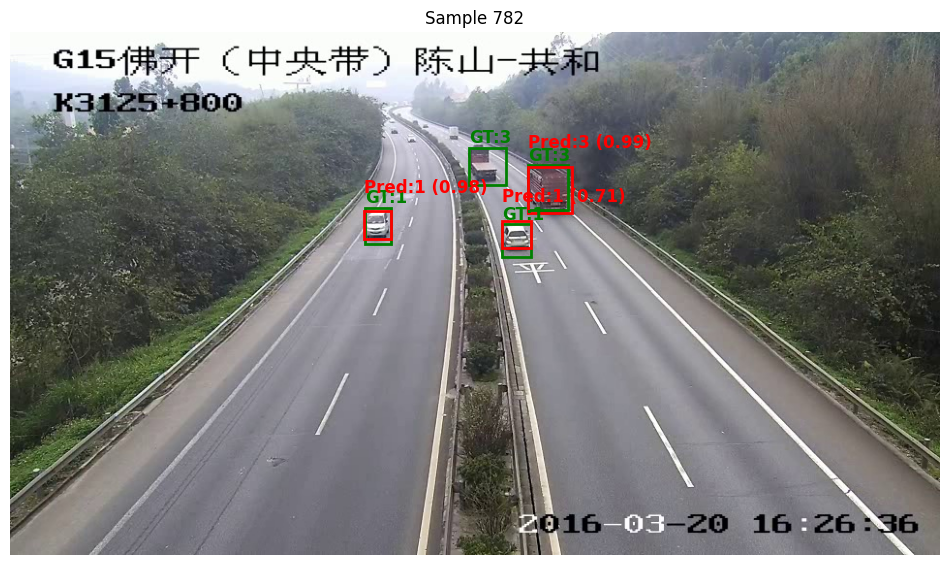

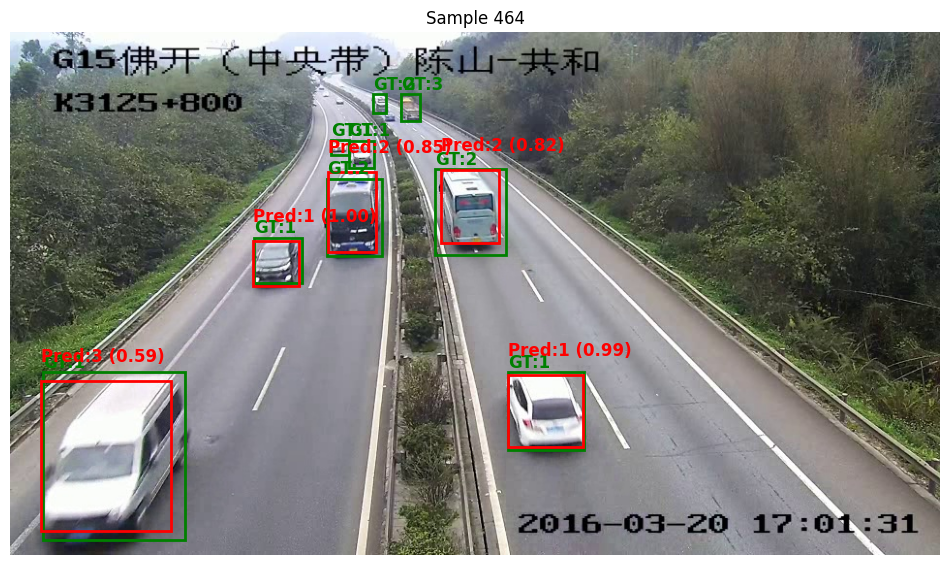

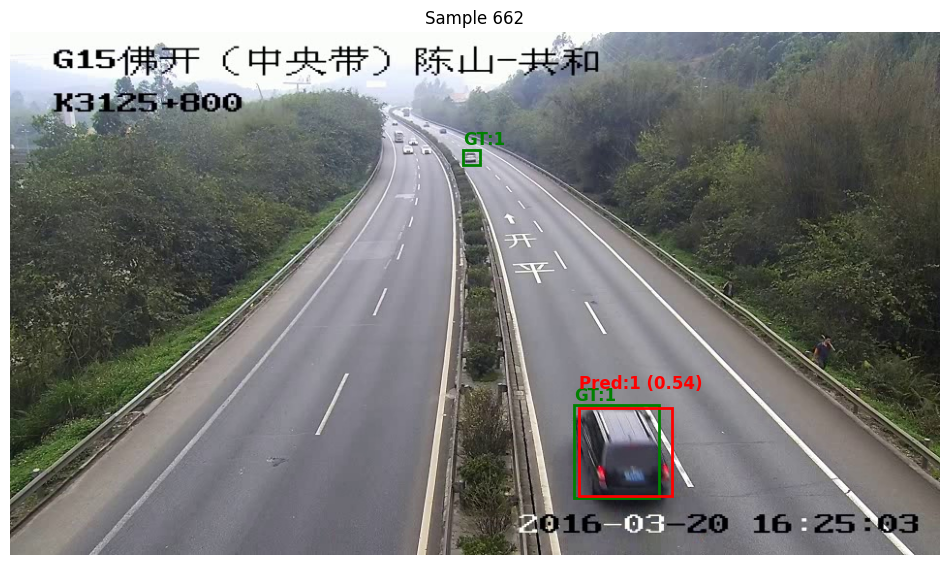

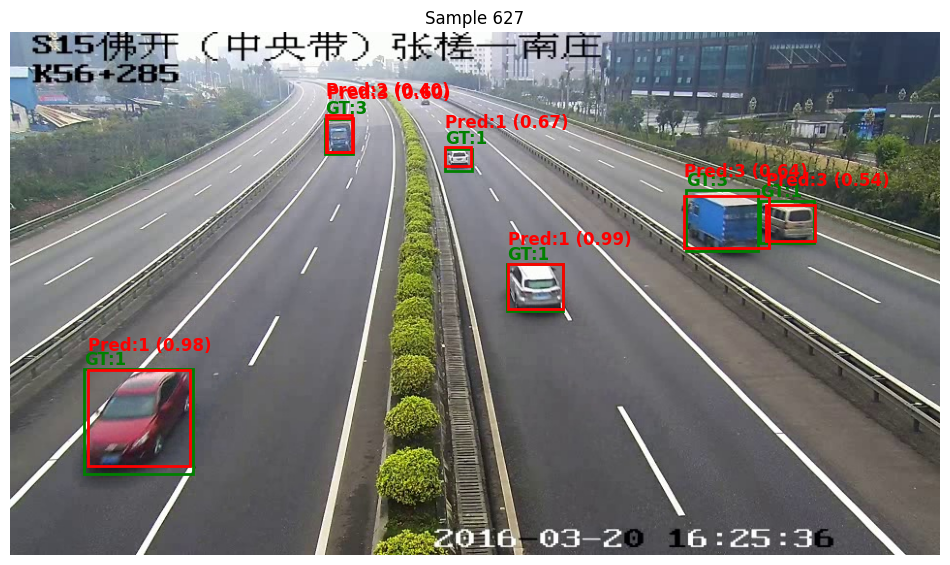

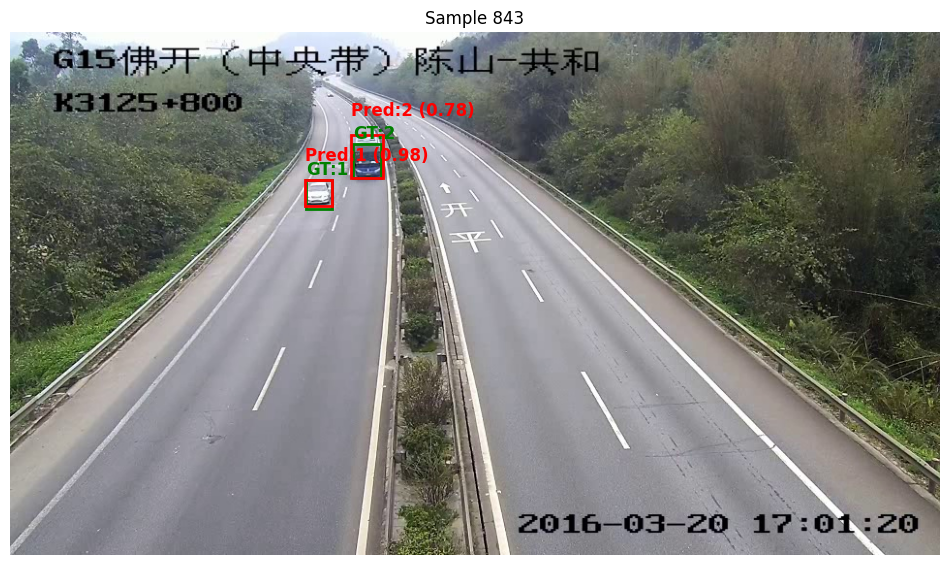

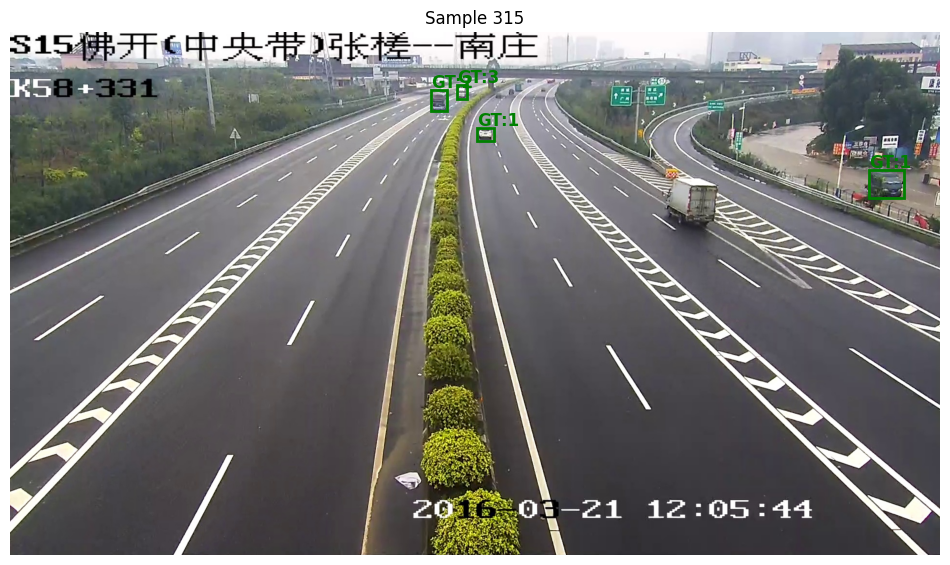

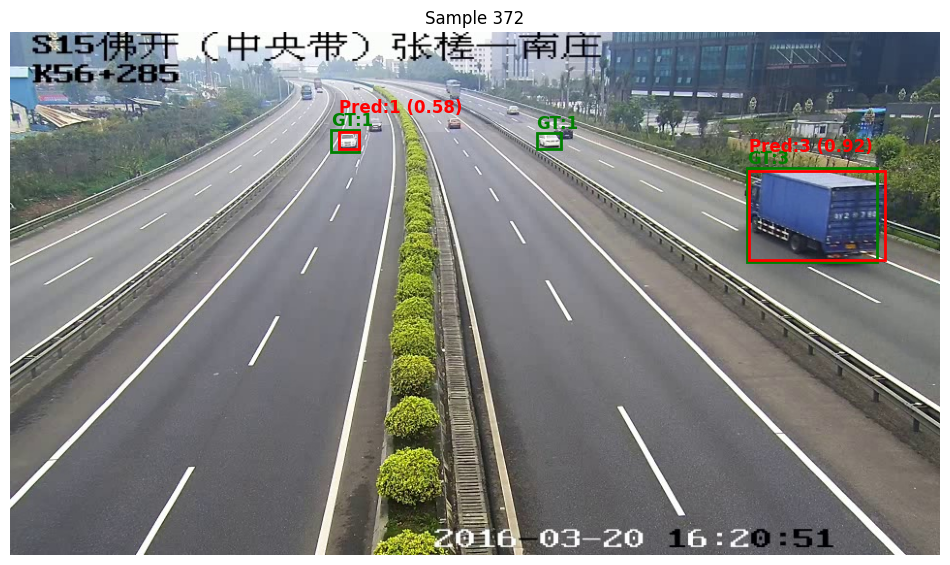

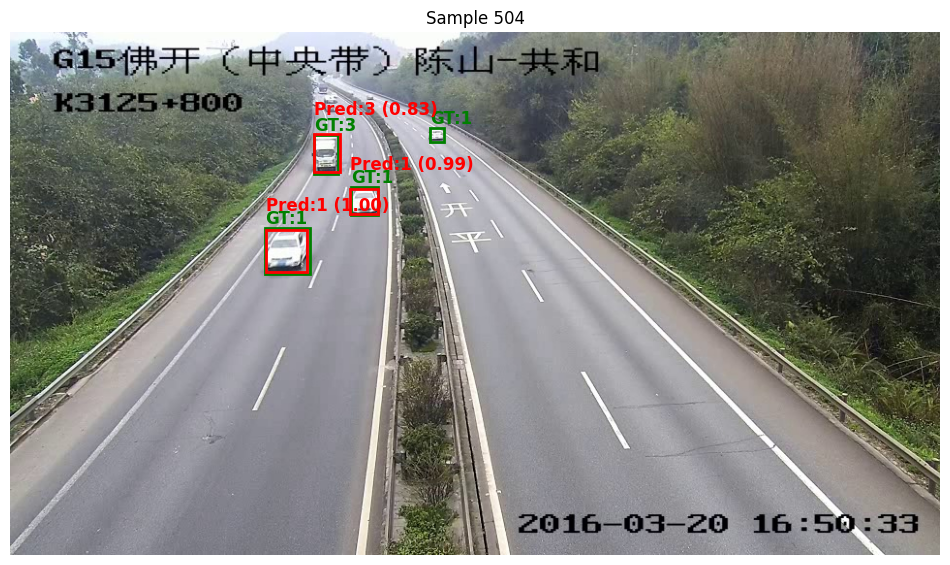

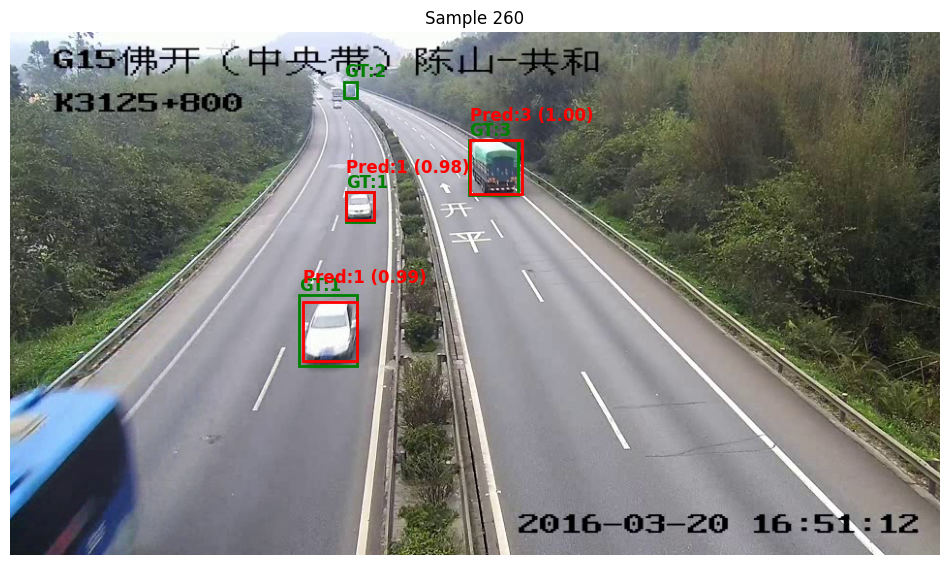

In [77]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
import cv2
import torch

def plot_image_with_boxes(image, gt_boxes, gt_labels, pred_boxes=None, pred_labels=None, pred_scores=None, title=""):
    """
    image: numpy array [H,W,C], BGR (will convert to RGB)
    gt_boxes: tensor [N,4]
    gt_labels: tensor [N]
    pred_boxes: tensor [M,4]
    pred_labels: tensor [M]
    pred_scores: tensor [M]
    """
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(1,1, figsize=(12,10))
    ax.imshow(image)

    # Draw ground truth boxes in green
    for i, box in enumerate(gt_boxes):
        x1, y1, x2, y2 = box
        w, h = x2 - x1, y2 - y1
        rect = patches.Rectangle((x1, y1), w, h, linewidth=2, edgecolor="g", facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1-5, f"GT:{gt_labels[i].item()}", color="g", fontsize=12, weight="bold")

    # Draw predicted boxes in red
    if pred_boxes is not None and len(pred_boxes) > 0:
        for i, box in enumerate(pred_boxes):
            x1, y1, x2, y2 = box
            w, h = x2 - x1, y2 - y1
            rect = patches.Rectangle((x1, y1), w, h, linewidth=2, edgecolor="r", facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1-20, f"Pred:{pred_labels[i].item()} ({pred_scores[i]:.2f})", color="r", fontsize=12, weight="bold")

    ax.set_title(title)
    plt.axis('off')
    plt.show()


# -----------------------------
# Randomly choose 10 test samples
# -----------------------------

test_dataset = LSVHDataSet(test_dataset_list, transforms = get_transform())

num_samples = len(test_dataset)
random_indices = random.sample(range(num_samples), 10)

model.eval()
with torch.no_grad():
    for i, idx in enumerate(random_indices):

        # Correctly get raw image path
        image_path = test_dataset[idx][2]
        gt_boxes = test_dataset[idx][1]['boxes']
        gt_labels = test_dataset[idx][1]['labels']

        # Read raw image
        image = cv2.imread(image_path)

        # Prepare tensor for model (normalize)
        img_tensor = torch.tensor(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)/255.0).permute(2,0,1).float().to(device)
        outputs = model([img_tensor])
        out = outputs[0]

        # Get predictions
        pred_boxes = out['boxes'].cpu()
        pred_labels = out['labels'].cpu()
        pred_scores = out['scores'].cpu()

        keep = pred_scores > 0.4
        pred_boxes = pred_boxes[keep]
        pred_labels = pred_labels[keep]
        pred_scores = pred_scores[keep]

        # Plot both GT and predictions
        plot_image_with_boxes(
            image, gt_boxes, gt_labels,
            pred_boxes, pred_labels, pred_scores,
            title=f"Sample {idx}"
        )


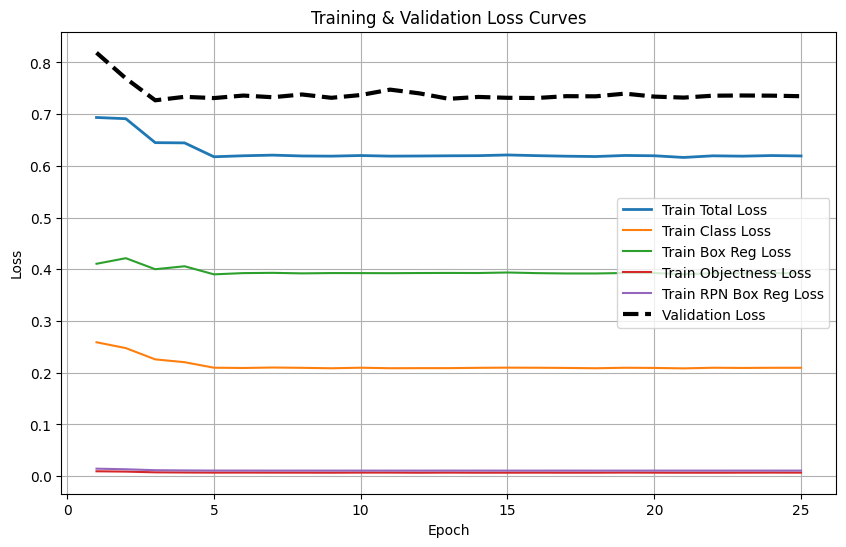

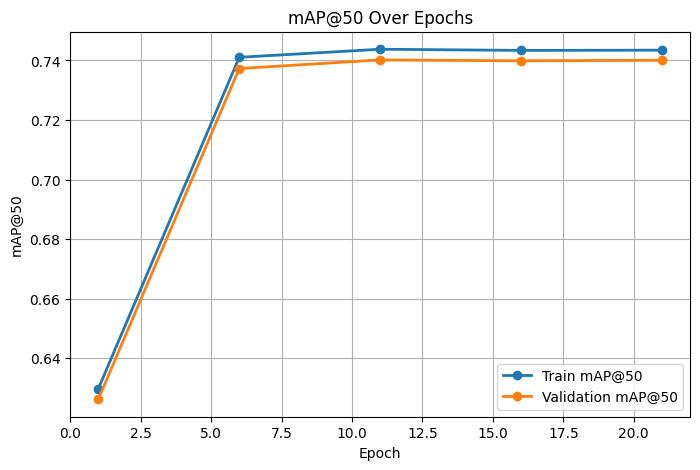

In [78]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================
# Extract epoch numbers
# ==========================
epochs = list(range(1, len(train_losses_history) + 1))

# ==========================
# Extract training loss curves
# ==========================
loss_total = [float(x["loss_total"]) for x in train_losses_history]
loss_classifier = [float(x["loss_classifier"]) for x in train_losses_history]
loss_box_reg = [float(x["loss_box_reg"]) for x in train_losses_history]
loss_objectness = [float(x["loss_objectness"]) for x in train_losses_history]
loss_rpn_box_reg = [float(x["loss_rpn_box_reg"]) for x in train_losses_history]

# ==========================
# Validation loss curve
# ==========================
val_loss = val_losses_history   # already a list of floats

# ==========================
# Extract mAP curves (sparse: every 5 epochs)
# ==========================
train_map_epochs = [d["epoch"] for d in train_map_history]
train_map_values = [d["mAP50_train"] for d in train_map_history]

val_map_epochs = [d["epoch"] for d in map_history]
val_map_values = [d["mAP50_val"] for d in map_history]

# ============================================================
# 1) Plot Training + Validation Loss
# ============================================================
plt.figure(figsize=(10, 6))

plt.plot(epochs, loss_total, label="Train Total Loss", linewidth=2)
plt.plot(epochs, loss_classifier, label="Train Class Loss")
plt.plot(epochs, loss_box_reg, label="Train Box Reg Loss")
plt.plot(epochs, loss_objectness, label="Train Objectness Loss")
plt.plot(epochs, loss_rpn_box_reg, label="Train RPN Box Reg Loss")

plt.plot(epochs, val_loss, label="Validation Loss", linewidth=3, linestyle="--", color="black")

plt.title("Training & Validation Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

# ============================================================
# 2) Plot Train mAP@50 and Val mAP@50
# ============================================================
plt.figure(figsize=(8, 5))

plt.plot(train_map_epochs, train_map_values, marker="o", label="Train mAP@50", linewidth=2)
plt.plot(val_map_epochs, val_map_values, marker="o", label="Validation mAP@50", linewidth=2)

plt.title("mAP@50 Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("mAP@50")
plt.grid(True)
plt.legend()
plt.show()


In [79]:
print("\n=== Evaluating on TEST SET ===")

test_dataloader = DataLoader(
    test_dataset,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers = 2,
    collate_fn = collate_fn
)

model.eval()  # ensure model is in eval mode

with torch.no_grad():
    test_map50 = evaluate_mAP(model, test_dataloader, device)

print(f"\n✅ Final Test mAP@50: {test_map50:.4f}")



=== Evaluating on TEST SET ===


100%|██████████| 106/106 [00:30<00:00,  3.51it/s]


✅ Final Test mAP@50: 0.6749
